In [524]:
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import tensorboard
from tqdm import tqdm

from src import models

%reload_ext autoreload
%autoreload 2

In [525]:
device = torch.device(
    "cuda:0" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu"
)

print('You are using the following device: ', device)

You are using the following device:  mps


In [526]:
full_train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor()
)

train_data, val_data = random_split(
    full_train_data,
    [50000, 10000],
    generator=torch.Generator().manual_seed(42)
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_data))

image, label = train_data[0]

print("Image shape:", image.shape)
print("Label:", label)

Training samples: 50000
Validation samples: 10000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Label: 6


In [527]:
hparams = {
    "batch_size" : 2 ** 8,
    "epochs" : 30,
    "learning_rate" : 5e-3,
    "p" : 0.1,
    "device" : device,
    "image_size" : 28,
    "image_channels" : 1,
    "latent_channels" : 8,
    "latent_dim" : 20,
    "latent_size" : 4,

    "num_classes" : 10,
}

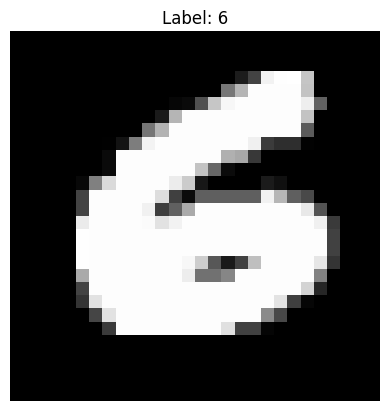

In [528]:
train_loader = DataLoader(
    train_data,
    batch_size=hparams["batch_size"],
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=hparams["batch_size"],
    shuffle=False
)


test_loader = DataLoader(
    test_data,
    batch_size=hparams["batch_size"],
    shuffle=False
)

image, label = train_data[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [529]:
def create_tqdm_bar(iterable, desc):
    return tqdm(enumerate(iterable),total=len(iterable), ncols=150, desc=desc)

def train_model(model, train_loader, val_loader, loss_func, tb_logger, epochs=10, name='AutoEncoder'):
    optimizer = model.optimizer
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=epochs * len(train_loader) / 5, gamma=0.7)
    model = model.to(device)
    validation_loss = 0

    for epoch in range(epochs):
        # train
        training_loss = 0
        training_loop = create_tqdm_bar(train_loader, desc=f'Training Epoch [{epoch}/{epochs}]')

        for train_iteration, batch in training_loop:
            if name.lower().strip() == "autoencoder":
                images, _ = batch
                loss = model.training_step(images, loss_func)
            else:
                loss = model.training_step(batch, loss_func)
            training_loss += loss.item()
            scheduler.step()

            training_loop.set_postfix(train_loss = "{:.8f}".format(training_loss / (train_iteration + 1)), val_loss = "{:.8f}".format(validation_loss))

            tb_logger.add_scalar(f'{name}/train_loss', loss.item(), epoch * len(train_loader) + train_iteration)

        # validation
        val_loop = create_tqdm_bar(val_loader, desc=f'Validation Epoch [{epoch}/{epochs}]')
        validation_loss = 0
        
        with torch.no_grad():
            for val_iteration, batch in val_loop:
                if name.lower().strip() == "autoencoder":
                    images, _ = batch
                    loss = model.validation_step(images, loss_func)
                else:
                    loss = model.validation_step(batch, loss_func)
                validation_loss += loss.item()

                val_loop.set_postfix(val_loss = "{:.8f}".format(validation_loss / (val_iteration + 1)))

                tb_logger.add_scalar(f'{name}/val_loss', validation_loss / (val_iteration + 1), epoch * len(val_loader) + val_iteration)

        validation_loss /= len(val_loader)


In [530]:
test_train_data = Subset(train_data, range(10))

test_train_loader = DataLoader(
    test_train_data,
    batch_size=10,
    shuffle=False
)


Pretraining Encoder using AutoEncoder

In [531]:
encoder = models.Encoder(hparams).to(device)
decoder = models.Decoder(hparams).to(device)
autoencoder = models.AutoEncoder(hparams=hparams, encoder=encoder, decoder=decoder).to(device)

loss_func = nn.MSELoss()
tb_logger = SummaryWriter("runs/autoencoder_test")
epochs = hparams.get('epochs', 5)
train_model(autoencoder, train_loader, val_loader, loss_func,  tb_logger, epochs=epochs, name='AutoEncoder')

Validation Epoch [29/30]: 100%|██████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  5.13it/s, val_loss=0.01188343]


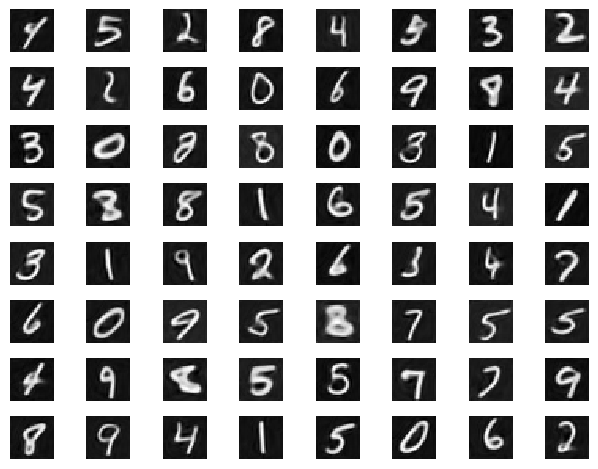

In [532]:
reconstructions = autoencoder.getReconstructions(val_loader)
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.axis('off')
    plt.imshow(reconstructions[i], cmap='gray', interpolation='none')
    
plt.tight_layout()

Using Pretrained Encoder with Classifier

In [533]:
classifier = models.Classifier(hparams=hparams, encoder=encoder)
loss_func = nn.CrossEntropyLoss()

train_model(classifier, train_loader, val_loader, loss_func, tb_logger, epochs=epochs, name='Classifier')

Validation Epoch [29/30]: 100%|██████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 20.05it/s, val_loss=0.07637300]


In [534]:
test_acc = classifier.getAcc(test_loader)[1]*100
print(f"Test accuracy with pretraining: {test_acc}%")

Test accuracy with pretraining: 98.49%


Now testing on handdrawn digits

In [535]:
from PIL import Image
from pathlib import Path
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

image_dir = Path("hand_drawn_images")
images = []

for i in range(10):
    image = Image.open(image_dir / f"{i}.png")
    image = transform(image)
    images.append(image)

images = torch.stack(images)

print(images.shape)

torch.Size([10, 1, 28, 28])


tensor([0, 6, 2, 3, 4, 6, 5, 2, 3, 4])


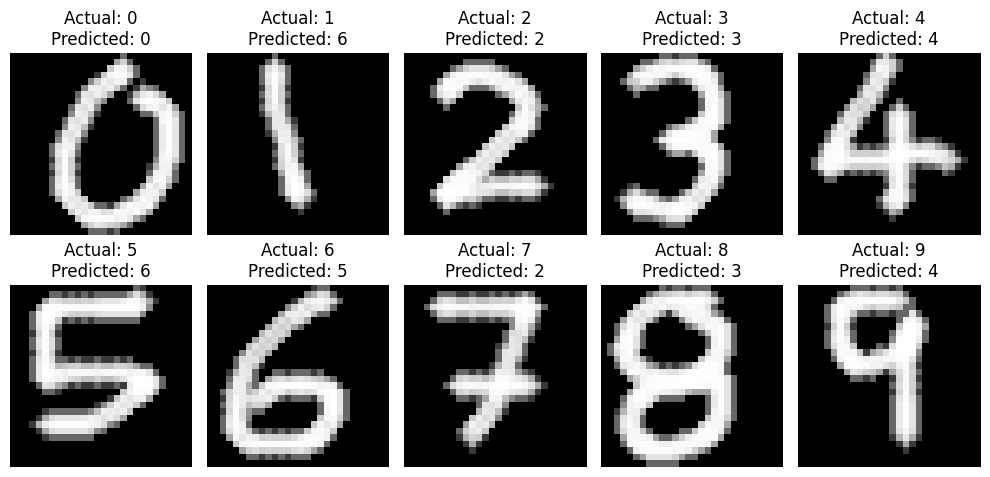

In [536]:
classifier.eval()
classifier.to(device)

with torch.no_grad():
    predictions = classifier(images.to(device))

predicted_labels = predictions.argmax(dim=1).cpu()

print(predicted_labels)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    
    actual = i
    predicted = predicted_labels[i].item()
    
    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Unfortunately the predictions on my handdrawn digits arent great. That is likely because the digits don't quite look like the MNIST dataset images.